In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [11]:
df = pd.read_csv("SpotifyFeatures.csv")

In [8]:
print(df.columns.tolist())

['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


In [9]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [30]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

X = df[features].copy()

print(X.shape)
X.head()

(232725, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576


In [31]:
print(X.isnull().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(232725, 9)


In [33]:
popular_df = df[df["popularity"] >= 85].copy()
print("Розмір після фільтрації:", popular_df.shape)

Розмір після фільтрації: (417, 21)


In [34]:
inertia = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[1516816.354389463, 1239295.177377865, 1102768.599423969, 986064.5228029899, 914368.8909298038, 849343.9095817338, 789394.4214886753, 749692.0177143402, 721974.8291720148, 696277.6984887974, 673736.5630581597, 651782.7006384747, 634053.9061155692, 621504.6072480045]


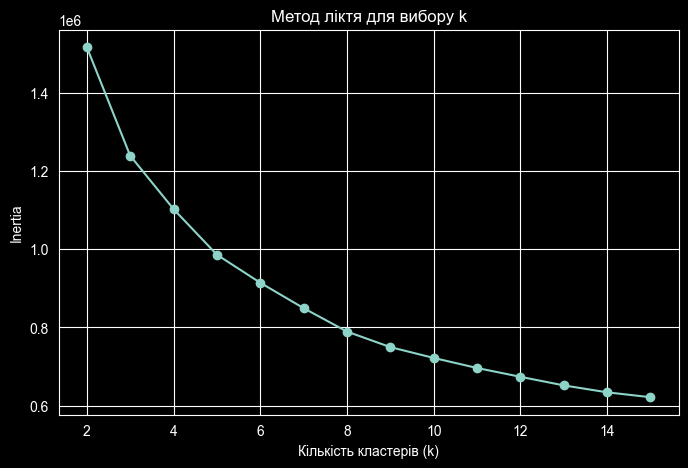

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Inertia")
plt.title("Метод ліктя для вибору k")
plt.grid(True)
plt.show()

In [36]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print(df["cluster"].value_counts())

cluster
2    84785
1    65206
0    45056
4    27536
3    10142
Name: count, dtype: int64


In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print(X_pca.shape)

(232725, 2)


In [38]:
popular_df = df[df["popularity"] >= 85].copy()
print(popular_df.shape)

(417, 21)


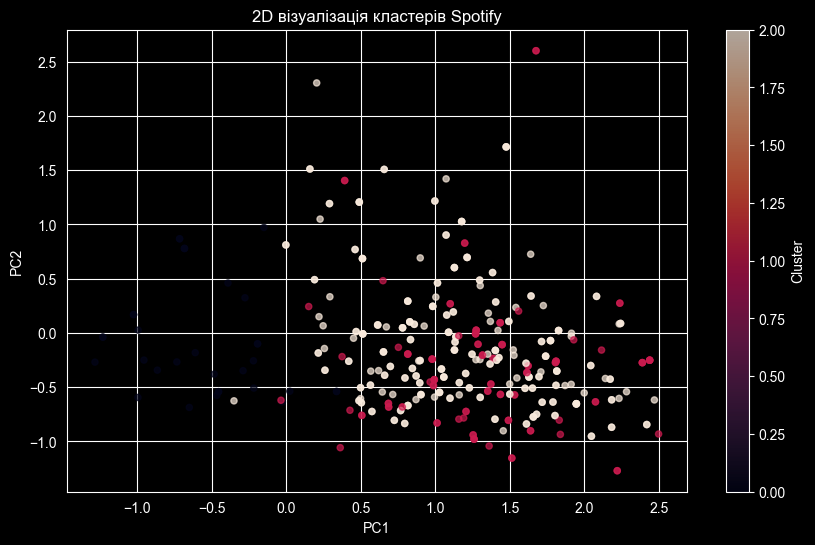

In [40]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    popular_df["PC1"],
    popular_df["PC2"],
    c=popular_df["cluster"],
    s=20,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D візуалізація кластерів Spotify")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [41]:
cluster_stats = df.groupby("cluster")[features].mean()
cluster_stats

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.503398,0.330317,-12.067212,0.065421,0.700776,0.065094,0.179147,0.333459,111.712266
1,0.503533,0.766553,-5.945379,0.093628,0.100463,0.091459,0.244616,0.432824,142.728339
2,0.704371,0.668754,-7.057443,0.104930,0.193868,0.059814,0.172164,0.638371,108.818007
3,0.562819,0.663492,-11.987054,0.877278,0.789213,0.001191,0.729041,0.414694,98.020536
4,0.293137,0.166330,-20.912220,0.045703,0.842787,0.745694,0.146178,0.155917,102.543763


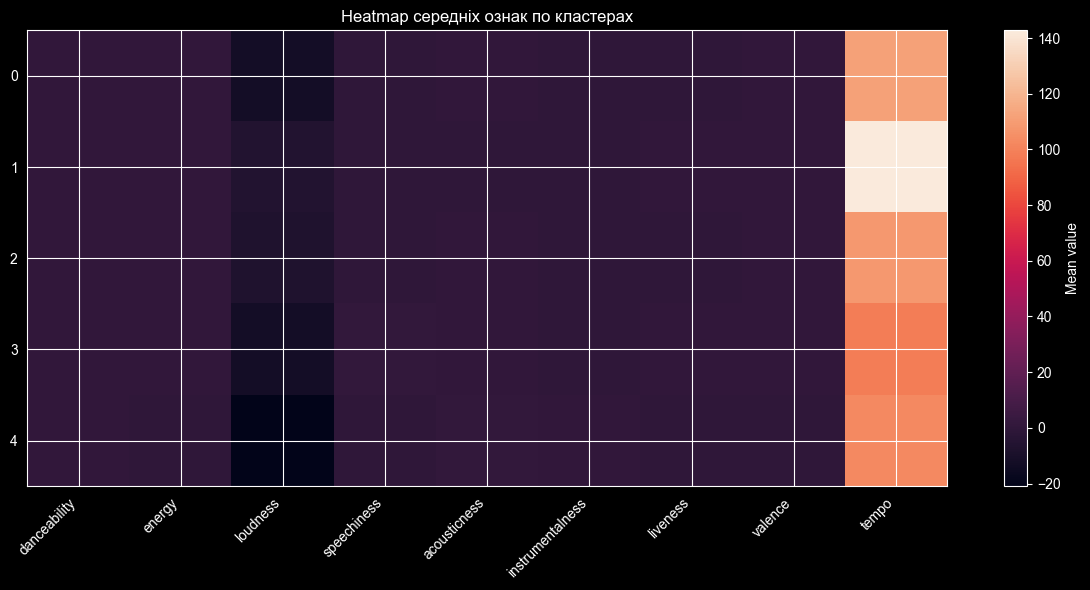

In [42]:
plt.figure(figsize=(12, 6))
plt.imshow(cluster_stats, aspect="auto")
plt.colorbar(label="Mean value")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(cluster_stats.index)), cluster_stats.index)
plt.title("Heatmap середніх ознак по кластерах")
plt.tight_layout()
plt.show()

In [43]:
for cluster_id in cluster_stats.index:
    print(f"\nКластер {cluster_id}")
    print(cluster_stats.loc[cluster_id].sort_values(ascending=False).head(3))


Кластер 0
tempo           111.712266
acousticness      0.700776
danceability      0.503398
Name: 0, dtype: float64

Кластер 1
tempo           142.728339
energy            0.766553
danceability      0.503533
Name: 1, dtype: float64

Кластер 2
tempo           108.818007
danceability      0.704371
energy            0.668754
Name: 2, dtype: float64

Кластер 3
tempo           98.020536
speechiness      0.877278
acousticness     0.789213
Name: 3, dtype: float64

Кластер 4
tempo               102.543763
acousticness          0.842787
instrumentalness      0.745694
Name: 4, dtype: float64
